<a href="https://colab.research.google.com/github/aarishaarif/Supervised-Machine-Learning-Models/blob/main/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.model_selection import train_test_split

In [ ]:
data = pd.read_csv('/content/Loan Eligibility Prediction.csv')
data.head()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y


In [ ]:
data.shape

(614, 13)

In [ ]:
data.describe()

,Customer_ID,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,307.500000,0.856678,5403.459283,1621.245798,142.022801,338.892508,0.850163
std,177.390811,1.216651,6109.041673,2926.248369,87.083089,69.716355,0.357203
min,1.000000,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000
25%,154.250000,0.000000,2877.500000,0.000000,98.000000,360.000000,1.000000
50%,307.500000,0.000000,3812.500000,1188.500000,125.000000,360.000000,1.000000
75%,460.750000,2.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,614.000000,4.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         614 non-null    int64  
 1   Gender              614 non-null    object 
 2   Married             614 non-null    object 
 3   Dependents          614 non-null    int64  
 4   Education           614 non-null    object 
 5   Self_Employed       614 non-null    object 
 6   Applicant_Income    614 non-null    int64  
 7   Coapplicant_Income  614 non-null    float64
 8   Loan_Amount         614 non-null    int64  
 9   Loan_Amount_Term    614 non-null    int64  
 10  Credit_History      614 non-null    int64  
 11  Property_Area       614 non-null    object 
 12  Loan_Status         614 non-null    object 
dtypes: float64(1), int64(6), object(6)
memory usage: 62.5+ KB


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.dtypes

,0
Customer_ID,int64
Gender,object
Married,object
Dependents,int64
Education,object
Self_Employed,object
Applicant_Income,int64
Coapplicant_Income,float64
Loan_Amount,int64
Loan_Amount_Term,int64


In [ ]:
data.drop(columns=['Customer_ID'],inplace=True)

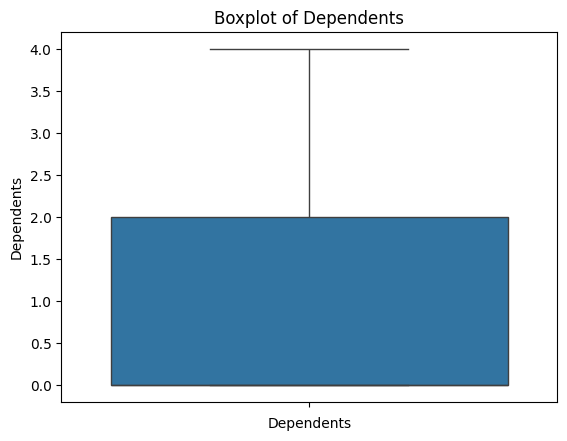

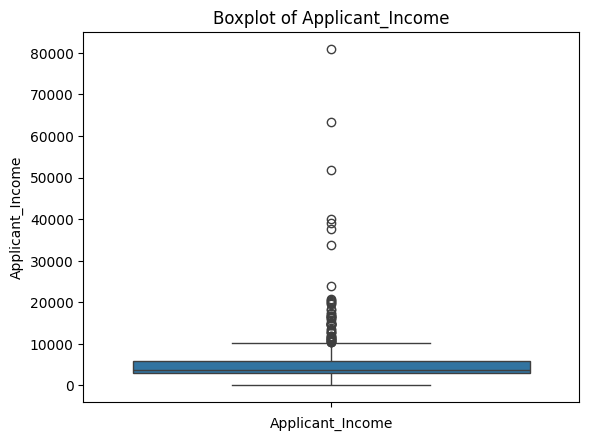

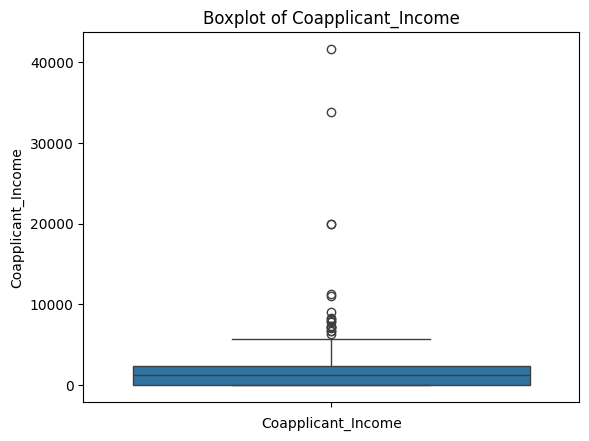

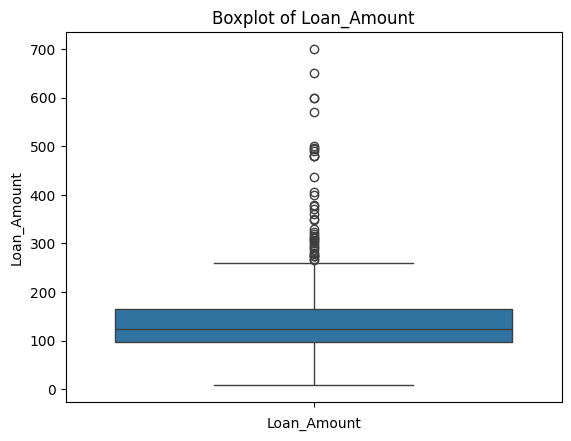

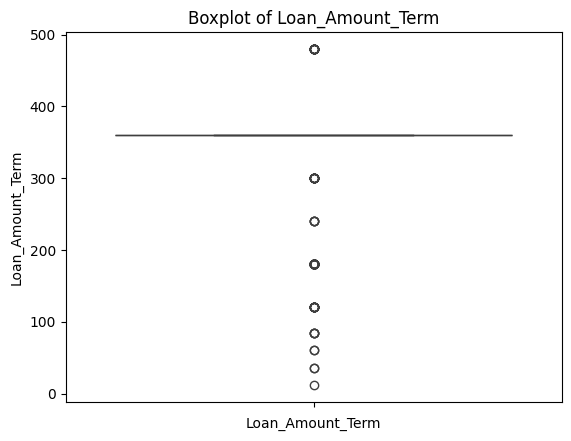

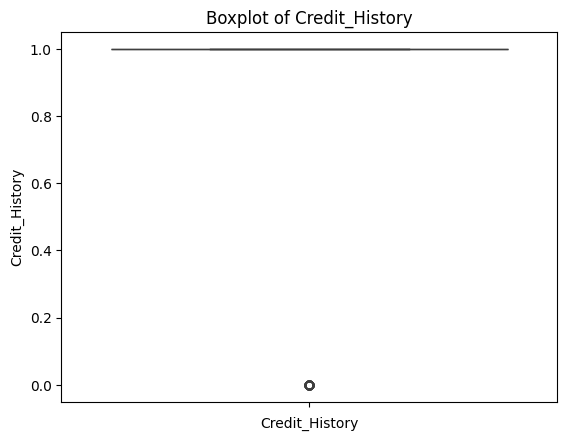

In [ ]:
num_cols = data.select_dtypes(include = ['int64','float64'])
for col in num_cols:
   plt.figure()
   sns.boxplot(data[col])
   plt.title(f'Boxplot of {col}')
   plt.xlabel(col)
   plt.show()


In [ ]:
outlier_summary = {}

for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower) | (data[col] > upper)]

    outlier_summary[col] = len(outliers)

print(outlier_summary)

{'Dependents': 0, 'Applicant_Income': 50, 'Coapplicant_Income': 18, 'Loan_Amount': 41, 'Loan_Amount_Term': 97, 'Credit_History': 92}


In [ ]:
import pandas as pd

outlier_data = pd.DataFrame(list(outlier_summary.items()),
                         columns=['Column', 'Outlier_Count'])

outlier_data = outlier_data.sort_values(by='Outlier_Count', ascending=False)

print(outlier_data)

               Column  Outlier_Count
4    Loan_Amount_Term             97
5      Credit_History             92
1    Applicant_Income             50
3         Loan_Amount             41
2  Coapplicant_Income             18
0          Dependents              0


In [ ]:
for col in num_cols:
  Q1 = data[col].quantile(0.25)
  Q3 = data[col].quantile(0.75)
  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  data[col] = data[col].clip(lower, upper)

In [ ]:
outlier_summary = {}

for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower) | (data[col] > upper)]

    outlier_summary[col] = len(outliers)

print(outlier_summary)

{'Dependents': 0, 'Applicant_Income': 0, 'Coapplicant_Income': 0, 'Loan_Amount': 0, 'Loan_Amount_Term': 0, 'Credit_History': 0}


In [ ]:
data.tail()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,480,Male,Yes,2,Graduate,No,2947,1603.0,10,360,1,Urban,N
610,525,Male,No,0,Graduate,No,4680,2087.0,15,360,1,Semiurban,N
611,551,Male,Yes,2,Graduate,Yes,6633,0.0,25,360,0,Rural,N
612,552,Male,Yes,1,Not Graduate,No,2492,2375.0,30,360,1,Rural,Y
613,606,Male,Yes,0,Not Graduate,No,2400,3800.0,25,180,1,Urban,N


In [ ]:
nominal_col =['Gender','Married','Education','Self_Employed','Loan_Status']
ordinal_col = ['Property_Area']

In [ ]:
data = pd.get_dummies(data,columns=nominal_col,drop_first=True)

In [ ]:
le = LabelEncoder()
for col in ordinal_col:
   data[col] = le.fit_transform(data[col])

In [ ]:
data.dtypes

,0
Customer_ID,int64
Dependents,int64
Applicant_Income,int64
Coapplicant_Income,float64
Loan_Amount,int64
Loan_Amount_Term,int64
Credit_History,int64
Property_Area,int64
Gender_Male,bool
Married_Yes,bool


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data.drop('Loan_Status_Y' , axis=1)
y = data['Loan_Status_Y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = log_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
print('Accuracy:' , accuracy_score(y_test,y_pred))

Accuracy: 0.8211382113821138


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       False       0.95      0.47      0.63        40
        True       0.80      0.99      0.88        83

    accuracy                           0.82       123
   macro avg       0.87      0.73      0.76       123
weighted avg       0.85      0.82      0.80       123



In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred))


[[19 21]
 [ 1 82]]


In [ ]:
y_prob = log_model.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import roc_curve

fpr,tpr,thresholds = roc_curve(y_test,y_prob)

In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test,y_prob)
print('AUC:',auc)

AUC: 0.7512048192771084


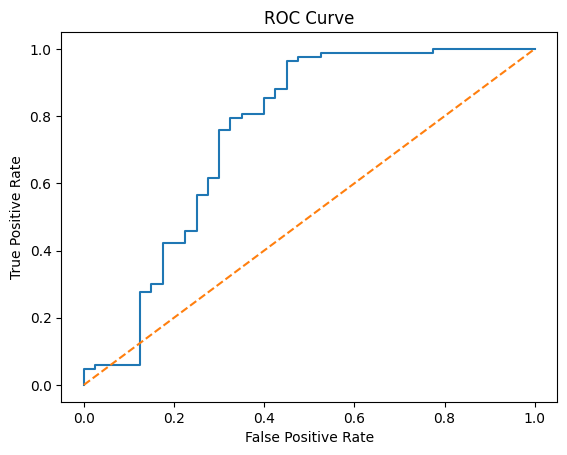

In [ ]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle='--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()